In [1]:
import os
import sys
from pathlib import Path

current = Path.cwd()
project_root = None
for candidate in [current, *current.parents]:
    if (candidate / "nasarbadi_helper.py").exists():
        project_root = candidate
        break

if project_root is None:
    project_root = current

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

os.chdir(project_root)

import mne
import pandas as pd
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import nasarbadi_helper


In [2]:
import os
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "nasarbadi_helper.py").exists():
    for candidate in project_root.parents:
        if (candidate / "nasarbadi_helper.py").exists():
            project_root = candidate
            break

os.chdir(project_root)
all_subjects = pd.read_csv(project_root / "datasets" / "metadata" / "nasarbadi_subject_index.csv")["ID"].tolist()


Pre-processing Steps:
1. IIR Butterworth Filter (Order 6, 0.5–60 Hz)
2. IIR Notch filter (50 Hz)
3. 4-second segments

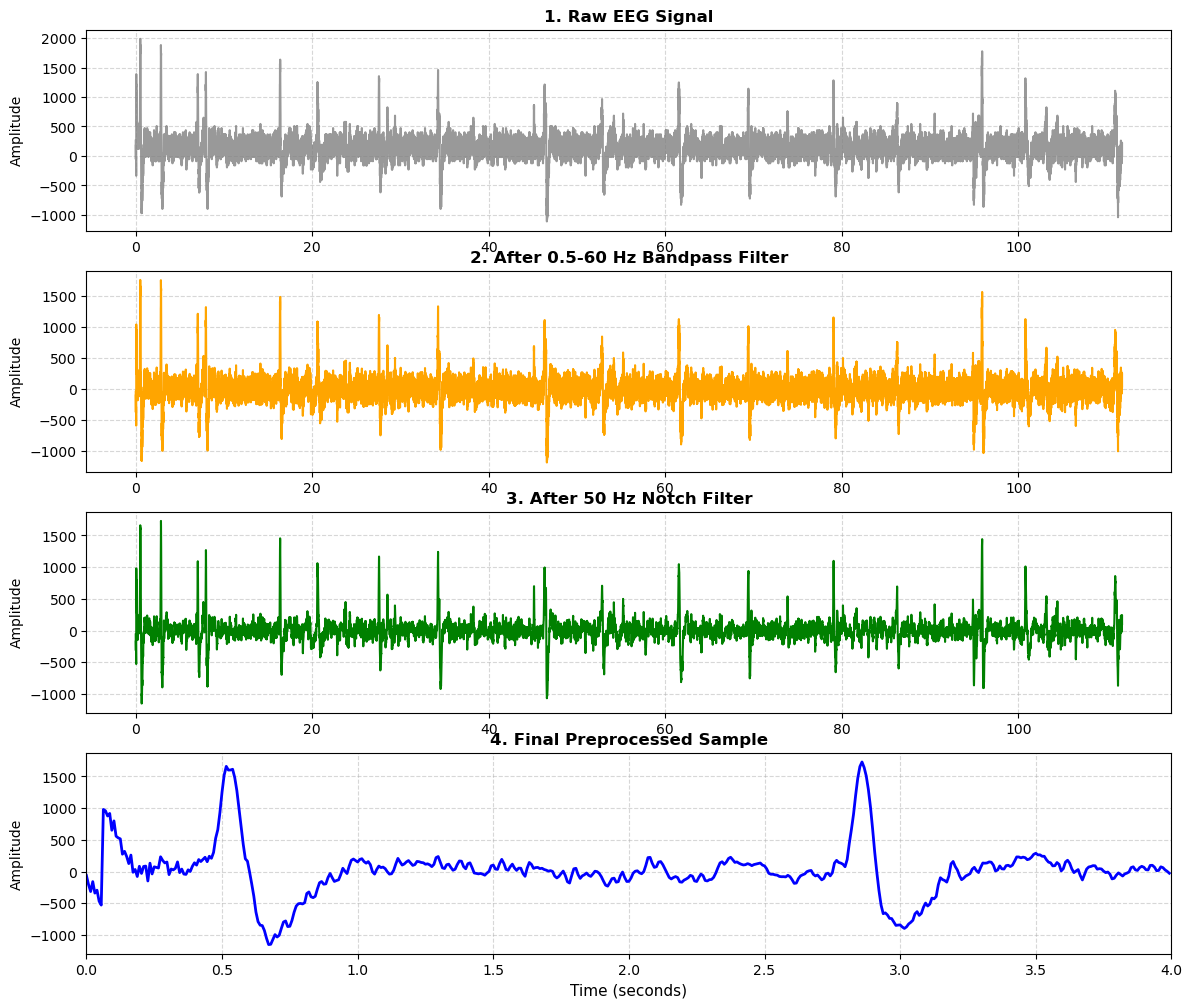

In [3]:
#IIR Butterworth Filter (Order 6, 0.5–60 Hz)
#Apply this filter to all the channels in all the subjects.

#Testing for the first subject for channel Fp1
subject_id = all_subjects[0]
subject_data, class_label = nasarbadi_helper.get_subject_info(subject_id)
fs = 128
data = subject_data["Fp1"]
t_full = np.arange(len(data)) / fs

sos_bandpass = signal.butter(6, [0.5,60], btype='bandpass', fs=128, output='sos')
filtered_bandpass = signal.sosfiltfilt(sos_bandpass, data)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

# Plot 1: Raw EEG Data
axes[0].plot(t_full, data, color='gray', alpha=0.8)
axes[0].set_title("1. Raw EEG Signal", fontsize=12, weight='bold')
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: After Bandpass
axes[1].plot(t_full, filtered_bandpass, color='orange')
axes[1].set_title("2. After 0.5-60 Hz Bandpass Filter", fontsize=12, weight='bold')
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, linestyle='--', alpha=0.5)


#IIR Notch filter (50 Hz)
b_notch, a_notch = signal.iirnotch(50.0, Q=30.0, fs=fs)
filtered_cleaned = signal.filtfilt(b_notch, a_notch, filtered_bandpass)

axes[2].plot(t_full, filtered_cleaned, color='green')
axes[2].set_title("3. After 50 Hz Notch Filter", fontsize=12, weight='bold')
axes[2].set_ylabel("Amplitude")
axes[2].grid(True, linestyle='--', alpha=0.5)

#4-second segments
segment_duration = 4  
samples_per_segment = segment_duration * fs
t_segment = np.arange(samples_per_segment) / fs
num_segments = len(filtered_cleaned) // samples_per_segment
segmented_data = filtered_cleaned[:num_segments * samples_per_segment].reshape(num_segments, samples_per_segment)

axes[3].plot(t_segment, segmented_data[0], color='blue', linewidth=2)
axes[3].set_title("4. Final Preprocessed Sample", fontsize=12, weight='bold')
axes[3].set_xlabel("Time (seconds)", fontsize=11)
axes[3].set_ylabel("Amplitude")
axes[3].set_xlim(0, 4)
axes[3].grid(True, linestyle='--', alpha=0.5)
plt.show()


In [4]:
print(subject_data.columns)

Index(['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7',
       'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz'],
      dtype='object')


In [ ]:
#Pre-processing Pipeline 

notebook_dir = Path.cwd() 
project_root = notebook_dir 
output_dir = project_root / "datasets" / "adhd-aid-data"

output_dir.mkdir(parents=True, exist_ok=True)

def iir_butterworth_filter(data, order=6, freq_range=[0.5, 60.0], fs=128):
    sos_bandpass = signal.butter(order, freq_range, btype='bandpass', fs=fs, output='sos')
    return signal.sosfiltfilt(sos_bandpass, data)

def iir_notch_filter(data, notch_freq=50.0, Q=30.0, fs=128):
    b_notch, a_notch = signal.iirnotch(notch_freq, Q=Q, fs=fs)
    return signal.filtfilt(b_notch, a_notch, data)

def four_sec_segment(data, segment_duration=4, fs=128):
    samples_per_segment = segment_duration * fs
    num_segments = len(data) // samples_per_segment
    return data[:num_segments * samples_per_segment].reshape(num_segments, samples_per_segment)

fs = 128

for subject_id in all_subjects:
    # Load raw data for this subject
    subject_data, class_label = nasarbadi_helper.get_subject_info(subject_id)
    
    subject_processed_channels = []
    for channel in subject_data.columns:
        raw_data = subject_data[channel].values
        
        # Preprocessing cascade
        bandpassed = iir_butterworth_filter(raw_data, fs=fs)
        cleaned = iir_notch_filter(bandpassed, fs=fs)
        segmented = four_sec_segment(cleaned, fs=fs)
        
        subject_processed_channels.append(segmented)
    
    subject_array = np.array(subject_processed_channels)
    
    file_name = f"subject_{subject_id}.npy"
    file_path = output_dir / file_name
    

    np.save(file_path, subject_array)
    print(f"Saved: {file_name} | Array Shape: {subject_array.shape}")

Saved: subject_v10p.npy | Array Shape: (19, 27, 512)
Saved: subject_v12p.npy | Array Shape: (19, 34, 512)
Saved: subject_v14p.npy | Array Shape: (19, 34, 512)
Saved: subject_v15p.npy | Array Shape: (19, 84, 512)
Saved: subject_v173.npy | Array Shape: (19, 47, 512)
Saved: subject_v18p.npy | Array Shape: (19, 48, 512)
Saved: subject_v19p.npy | Array Shape: (19, 45, 512)
Saved: subject_v1p.npy | Array Shape: (19, 23, 512)
Saved: subject_v20p.npy | Array Shape: (19, 69, 512)
Saved: subject_v21p.npy | Array Shape: (19, 32, 512)
Saved: subject_v22p.npy | Array Shape: (19, 23, 512)
Saved: subject_v24p.npy | Array Shape: (19, 32, 512)
Saved: subject_v25p.npy | Array Shape: (19, 19, 512)
Saved: subject_v27p.npy | Array Shape: (19, 56, 512)
Saved: subject_v28p.npy | Array Shape: (19, 53, 512)
Saved: subject_v29p.npy | Array Shape: (19, 47, 512)
Saved: subject_v30p.npy | Array Shape: (19, 42, 512)
Saved: subject_v31p.npy | Array Shape: (19, 22, 512)
Saved: subject_v32p.npy | Array Shape: (19, 35,

**Multi-Resolution Analysis and Feature Extraction**
1. DWT
2. EWT
3. VMD